#**CUSTOMER CHURN PREDICTION - LapisAI**

- **Kelompok :** 3  
- **Kelas :** TI-6A  
- **Anggota Kelompok 3 :**
  1. Naila Syakirotul Rizkiyah (2307411011)  
  2. Rizky Amelia Putri (2307411015)  
  3. Rifa Mardhatillah (2307411016)  
  4. Elviyanti (2307411020)  
  5. Azkia Intan Sahila (2307411021)  

##**Business Understanding**

Pada proyek Customer Churn Prediction Dashboard, perusahaan SaaS menghadapi masalah tingginya tingkat customer churn (8–12% per bulan) yang berdampak pada penurunan pendapatan, terutama dari pelanggan bernilai tinggi. Selama ini, identifikasi pelanggan berisiko masih bersifat deskriptif sehingga strategi retensi kurang efektif.

Oleh karena itu, diperlukan sistem prediksi berbasis machine learning yang dapat mengidentifikasi pelanggan berisiko churn secara dini dan menyajikan insight melalui dashboard. Sistem ini diharapkan membantu perusahaan dalam memahami faktor penyebab churn serta meningkatkan efektivitas strategi retensi.

**Tujuan bisnis proyek ini meliputi:**
- Mengurangi churn melalui deteksi dini.
- Mengoptimalkan strategi retensi berbasis risk scoring.
- Memberikan insight faktor penyebab churn.
- Mendukung pengambilan keputusan berbasis data.

**Keberhasilan diukur dari performa model** (akurasi ≥ 80% dan AUC-ROC > 0.75) serta kemampuan dashboard dalam memberikan insight yang actionable.

## **Data Understanding**

Dataset yang digunakan dalam proyek ini berupa data pelanggan SaaS yang disimpan dalam file customers_dataset.csv dengan jumlah sekitar 3.000 baris data dan 13 kolom fitur (campuran numerikal dan kategorikal). Menggambarkan perilaku dan karakteristik pelanggan sebuah perusahaan SaaS  dalam kaitannya dengan kemungkinan mereka berhenti berlangganan (churn).

**Tujuan Dataset:**
*   Menganalisis faktor-faktor yang paling mempengaruhi keputusan pelanggan untuk churn.
*   Membangun model machine learning untuk memprediksi risiko churn setiap pelanggan.
*   Mengklasifikasikan pelanggan ke dalam segmen risiko: Low, Medium, atau High

**Fitur Dataset:**
> customer_id = ID unik setiap pelanggan

> plan_type = Jenis paket layanan (Starter / Professional / Enterprise)

> contract_type = Jenis kontrak yang digunakan (Monthly / Annual)

> tenure_months = Lama berlangganan dalam bulan

> monthly_revenue = Pendapatan bulanan yang dihasilkan dari pelanggan

> monthly_usage_hrs = Total jam penggunaan layanan per bulan

> total_users = Jumlah pengguna aktif dalam satu akun

> feature_adoption_pct = Persentase fitur produk yang telah digunakan (%)

> support_tickets_last_90d = Jumlah tiket support yang diajukan dalam 90 hari terakhir

> last_login_days_ago = Jumlah hari sejak terakhir kali pelanggan login

> nps_score = Net Promoter Score — tingkat kepuasan pelanggan (0–10)

> payment_delay_count = Jumlah keterlambatan pembayaran yang pernah terjadi

> churned = Variabel target apakah pelanggan churn (1) atau tidak (0)






## **Data Preparation**

In [ ]:
!pip install gdown
import pandas as pd

In [ ]:
import gdown

file_id = "1cKWjqoELeLDJFI9tCNs3KoFCFmGdwh-x"
url = f"https://drive.google.com/uc?id={file_id}"

output = "customers_dataset.csv"
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1cKWjqoELeLDJFI9tCNs3KoFCFmGdwh-x
To: /content/customers_dataset.csv
100%|██████████| 180k/180k [00:00<00:00, 24.3MB/s]


'customers_dataset.csv'

In [ ]:
df = pd.read_csv("customers_dataset.csv")
df.head()

,customer_id,plan_type,contract_type,tenure_months,monthly_revenue,monthly_usage_hrs,total_users,feature_adoption_pct,support_tickets_last_90d,last_login_days_ago,nps_score,payment_delay_count,churned
0,C-0001,Starter,Monthly,19,112.58,20.1,4,73.6,0,34,0,4,1
1,C-0002,Starter,Annual,14,89.52,25.6,1,54.8,15,67,7,1,1
2,C-0003,Professional,Annual,23,797.96,136.1,9,66.0,1,36,1,5,0
3,C-0004,Starter,Monthly,25,57.24,16.2,2,15.2,11,37,4,0,1
4,C-0005,Starter,Monthly,28,58.13,12.5,1,63.6,6,11,3,3,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               3000 non-null   object 
 1   plan_type                 3000 non-null   object 
 2   contract_type             3000 non-null   object 
 3   tenure_months             3000 non-null   int64  
 4   monthly_revenue           3000 non-null   float64
 5   monthly_usage_hrs         3000 non-null   float64
 6   total_users               3000 non-null   int64  
 7   feature_adoption_pct      3000 non-null   float64
 8   support_tickets_last_90d  3000 non-null   int64  
 9   last_login_days_ago       3000 non-null   int64  
 10  nps_score                 3000 non-null   int64  
 11  payment_delay_count       3000 non-null   int64  
 12  churned                   3000 non-null   int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 304.8+ KB


,tenure_months,monthly_revenue,monthly_usage_hrs,total_users,feature_adoption_pct,support_tickets_last_90d,last_login_days_ago,nps_score,payment_delay_count,churned
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000
mean,24.789667,966.262923,88.160700,19.945667,52.268867,7.559333,44.671000,5.030333,2.51600,0.512333
std,13.802159,1294.362355,73.053699,25.997744,24.165849,4.605383,26.191018,3.166611,1.71213,0.499931
min,1.000000,50.100000,2.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,13.000000,142.737500,33.575000,3.000000,31.275000,4.000000,22.000000,2.000000,1.00000,0.000000
50%,25.000000,374.510000,59.300000,8.000000,51.900000,8.000000,45.000000,5.000000,3.00000,1.000000
75%,36.000000,1017.562500,125.700000,20.000000,73.400000,11.000000,67.000000,8.000000,4.00000,1.000000
max,48.000000,4994.580000,299.400000,100.000000,95.000000,15.000000,90.000000,10.000000,5.00000,1.000000


### **1. Cek Missing Values**

In [ ]:
df.isnull().sum()

,0
customer_id,0
plan_type,0
contract_type,0
tenure_months,0
monthly_revenue,0
monthly_usage_hrs,0
total_users,0
feature_adoption_pct,0
support_tickets_last_90d,0
last_login_days_ago,0


### **2. Cek Duplikasi Data**

In [ ]:
df.duplicated().sum()

np.int64(0)

### **3. EDA**

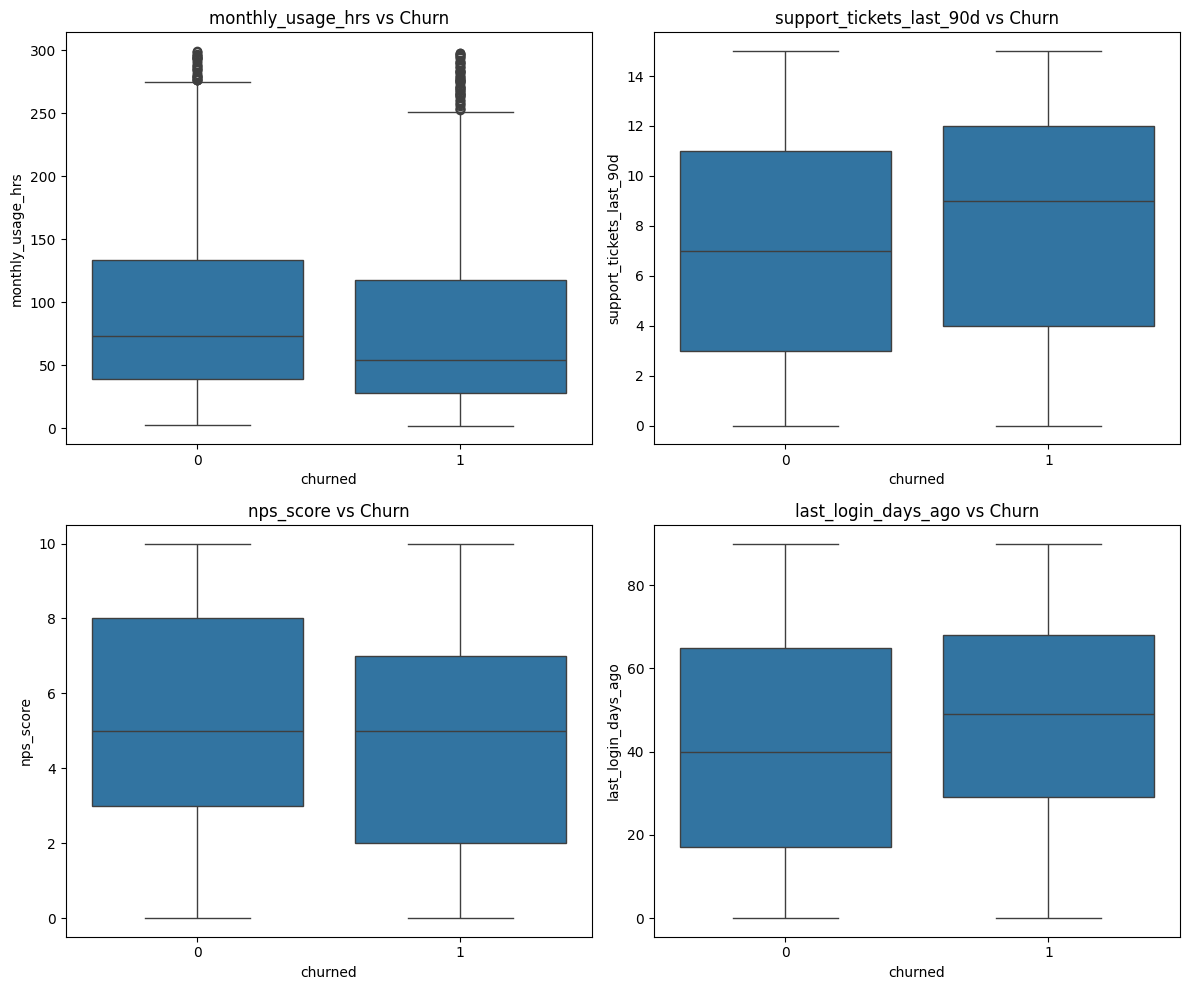

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'monthly_usage_hrs',
    'support_tickets_last_90d',
    'nps_score',
    'last_login_days_ago'
]

plt.figure(figsize=(12, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='churned', y=feature, data=df)
    plt.title(f'{feature} vs Churn')

plt.tight_layout()
plt.show()

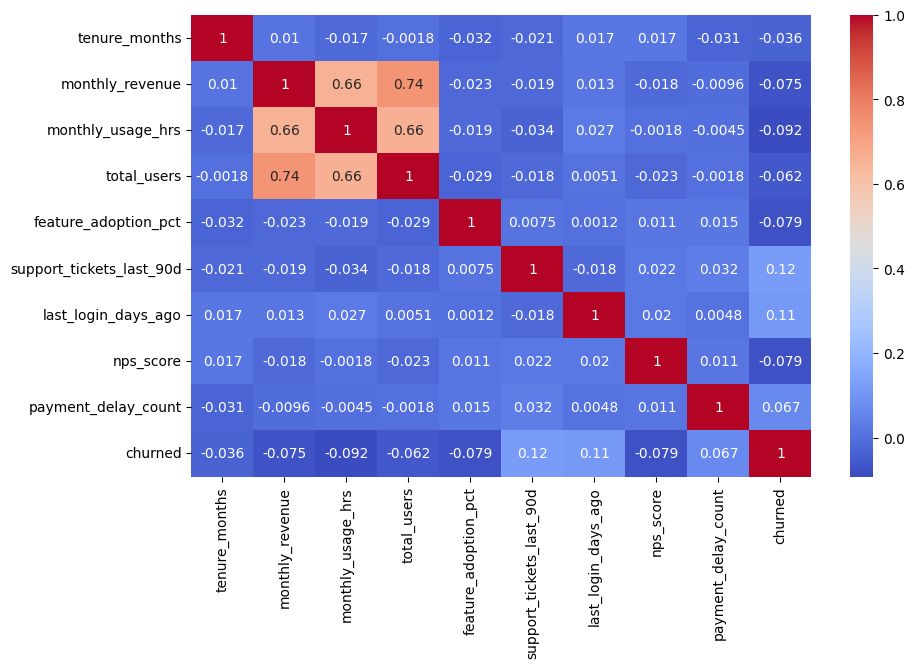

In [ ]:
#Heatmap Korelasi antar fitur
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


PLAN TYPE
plan_type
Starter         1174
Professional    1034
Enterprise       792
Name: count, dtype: int64

CONTRACT TYPE
contract_type
Monthly    1673
Annual     1327
Name: count, dtype: int64

CHURNED
churned
1    1537
0    1463
Name: count, dtype: int64


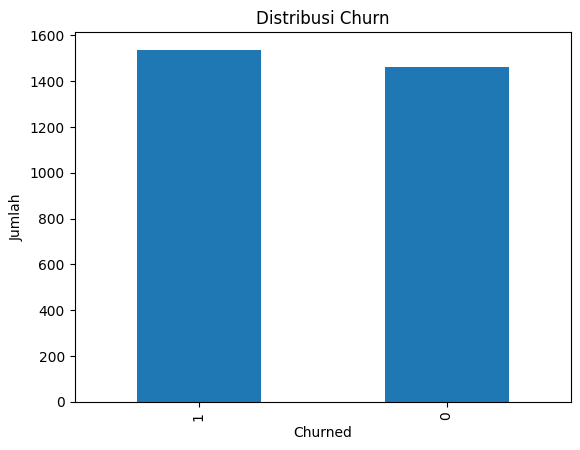

In [ ]:
import matplotlib.pyplot as plt

#Cek Distribusi
# Value counts
print("\nPLAN TYPE")
print(df['plan_type'].value_counts())

print("\nCONTRACT TYPE")
print(df['contract_type'].value_counts())

print("\nCHURNED")
print(df['churned'].value_counts())

# Visualisasi churn
df['churned'].value_counts().plot(kind='bar')
plt.title("Distribusi Churn")
plt.xlabel("Churned")
plt.ylabel("Jumlah")
plt.show()

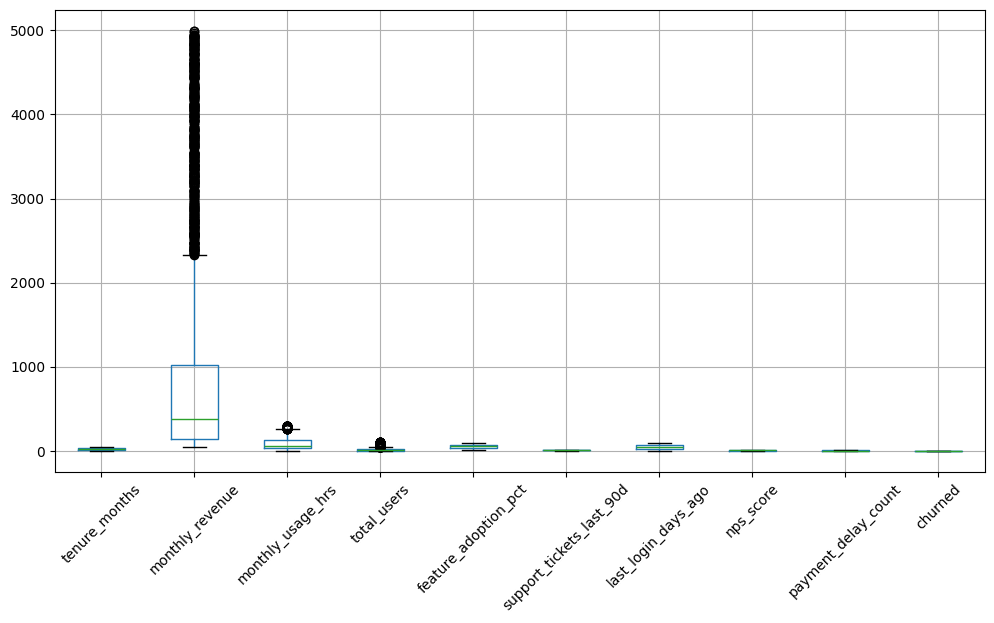

In [ ]:
#Cek Outlier
df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

### **4. Encoding Data Kategorikal**

In [ ]:
# One-Hot Encoding untuk plan_type
df = pd.get_dummies(df, columns=['plan_type'], prefix='plan')
print(df[['plan_Starter', 'plan_Professional', 'plan_Enterprise']].head())

   plan_Starter  plan_Professional  plan_Enterprise
0          True              False            False
1          True              False            False
2         False               True            False
3          True              False            False
4          True              False            False


In [ ]:
# Label Encoding untuk contract_type
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['contract_encoded'] = le.fit_transform(df['contract_type'])

print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
df[['contract_type', 'contract_encoded']].head()

Mapping: {'Annual': np.int64(0), 'Monthly': np.int64(1)}


,contract_type,contract_encoded
0,Monthly,1
1,Annual,0
2,Annual,0
3,Monthly,1
4,Monthly,1


### **5. Drop Kolom yang Tidak Perlu**

In [ ]:
df = df.drop(columns=['customer_id'])

In [ ]:
# Drop kolom string yang sudah di-encode
df = df.drop(columns=['contract_type'])

### **6. Split Data**

In [ ]:
# Split data
from sklearn.model_selection import train_test_split

X = df.drop('churned', axis=1)
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Churn rate train: {y_train.mean():.2%}")

Train size: (2400, 13)
Test size: (600, 13)
Churn rate train: 52.04%


### **7. Handle Outlier (Capping)**

In [ ]:
# List kolom numerik
num_cols = ['monthly_revenue', 'monthly_usage_hrs', 'tenure_months']

for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Capping di train
    X_train[col] = X_train[col].clip(lower, upper)

    # Capping di test (pakai batas dari train)
    X_test[col] = X_test[col].clip(lower, upper)

### **8. Scaling**

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Data Modelling**

### **1. Logistic Regression**

              precision    recall  f1-score   support

   Not Churn       0.58      0.66      0.62       276
       Churn       0.67      0.60      0.63       324

    accuracy                           0.62       600
   macro avg       0.63      0.63      0.62       600
weighted avg       0.63      0.62      0.62       600

ROC-AUC: 0.6568


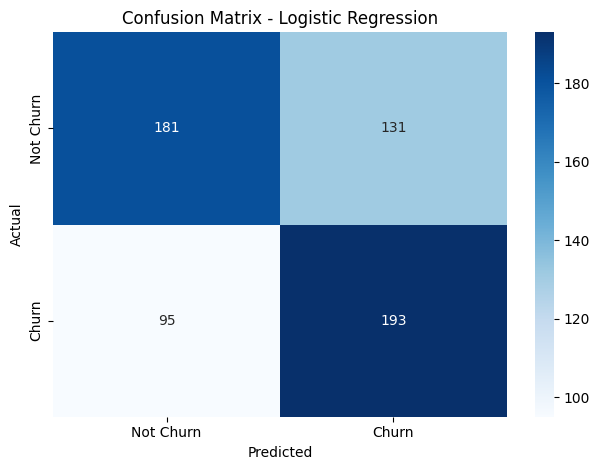

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_pred  = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(lr_pred, y_test, target_names=['Not Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### **2. Random Forest**

              precision    recall  f1-score   support

   Not Churn       0.56      0.64      0.60       271
       Churn       0.66      0.58      0.62       329

    accuracy                           0.61       600
   macro avg       0.61      0.61      0.61       600
weighted avg       0.62      0.61      0.61       600

ROC-AUC: 0.6390


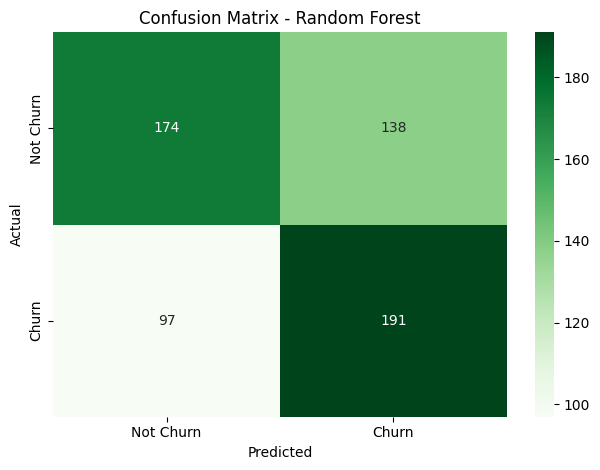

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred  = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluasi
print(classification_report(rf_pred, y_test, target_names=['Not Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### **3. Xgboost**

              precision    recall  f1-score   support

   Not Churn       0.53      0.62      0.57       264
       Churn       0.66      0.56      0.61       336

    accuracy                           0.59       600
   macro avg       0.59      0.59      0.59       600
weighted avg       0.60      0.59      0.59       600

ROC-AUC: 0.6212


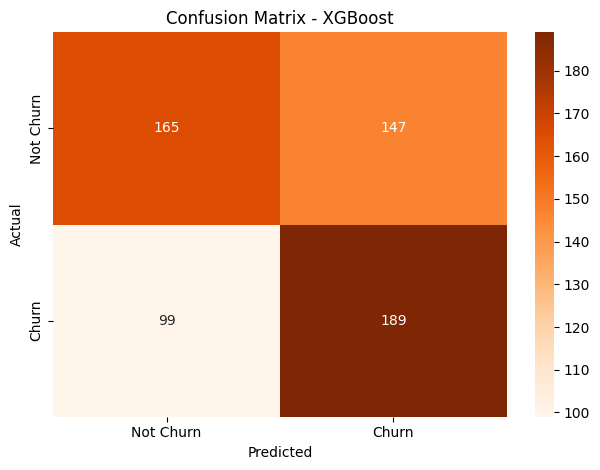

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train_scaled, y_train)

xgb_pred  = xgb_model.predict(X_test_scaled)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluasi
print(classification_report(xgb_pred, y_test, target_names=['Not Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## **Evaluation**

TABEL PERBANDINGAN MODEL
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.6233     0.5957  0.6701    0.6307   0.6568
Random Forest          0.6083     0.5805  0.6632    0.6191   0.6390
XGBoost                0.5900     0.5625  0.6562    0.6058   0.6212


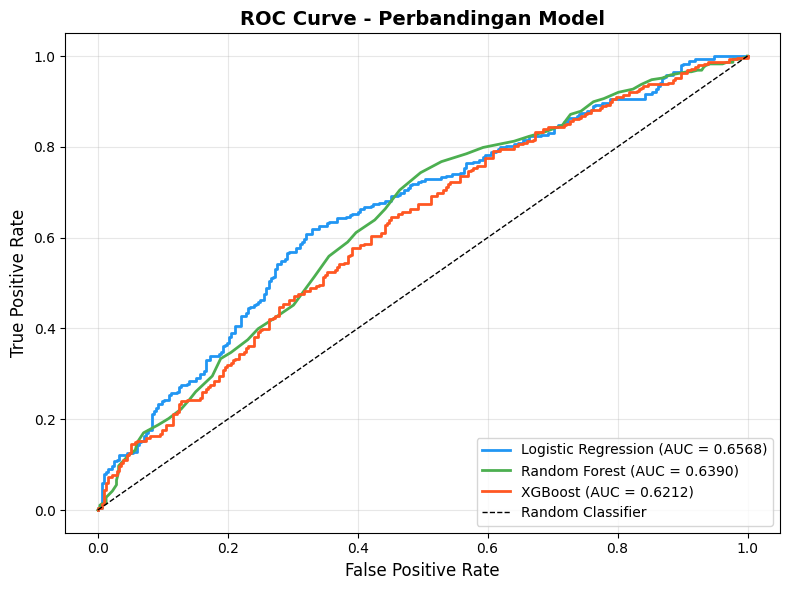

In [ ]:
#Perbandingan akurasi model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report

# Kumpulkan semua metrik
comparison = {
    'Logistic Regression': {
        'y_pred' : lr_pred,
        'y_proba': lr_proba
    },
    'Random Forest': {
        'y_pred' : rf_pred,
        'y_proba': rf_proba
    },
    'XGBoost': {
        'y_pred' : xgb_pred,
        'y_proba': xgb_proba
    }
}

rows = []
for name, v in comparison.items():
    report = classification_report(y_test, v['y_pred'], output_dict=True)
    rows.append({
        'Model'    : name,
        'Accuracy' : round(report['accuracy'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall'   : round(report['1']['recall'], 4),
        'F1-Score' : round(report['1']['f1-score'], 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, v['y_proba']), 4)
    })

df_comparison = pd.DataFrame(rows).set_index('Model')
print("TABEL PERBANDINGAN MODEL")
print(df_comparison)

#ROC Curve
from sklearn.metrics import roc_curve
plt.figure(figsize=(8, 6))

for (name, v), color in zip(comparison.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    auc = roc_auc_score(y_test, v['y_proba'])
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Perbandingan Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()